# Sentinel-2 data: acess Time Series of images, plot, and compare NDVI series for 4 bioms

Considering one small area from 4 different biomasses in Brazil

| Biomass | Chatacteristics | Coordinates (lon,lat)|
|---------|-----------------|----------------------|
| Caatinga | Semi-arid, highly seasonal, drops leaves in dry season | -40.50, -9.50 <br>(Bahia/Pernambuco border) |
| Atlantic Forest |	Dense, humid evergreen/semi-deciduous broadleaf | -48.00, -24.50 <br>(São Paulo state) |
| Pampa |	Natural grasslands with interspersed shrublands | -54.00, -30.00 <br>(Rio Grande do Sul) |
| Pantanal |	Seasonal wetlands, highly dependent on flood pulse | -56.50, -19.00 <br>(Mato Grosso do Sul) |

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Authenticate and Initialize
ee.Authenticate()
ee.Initialize(project='your-project')

In [ ]:
biomes = {
    'caatinga': ee.Geometry.Point([-40.50, -9.50]),
    'atlantic_forest': ee.Geometry.Point([-48.00, -24.50]),
    'pampa': ee.Geometry.Point([-54.00, -30.00]),
    'pantanal': ee.Geometry.Point([-56.50, -19.00])
}

In [ ]:
# 2. Cloud Masking Function for Sentinel-2 using the SCL (Scene Classification) band
def maskS2clouds(image):
    scl = image.select('SCL')
    # Keep pixels classified as vegetation (4), bare soil (5), water (6), unclassified (7)
    # Mask out clouds (9), cirrus (10), cloud shadows (3)
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

# 3. Add NDVI Function
def addNDVI(image):
    # Sentinel-2: NIR is Band 8, Red is Band 4
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

In [ ]:
# Extract Time Series Data per regio of interest
roi = biomes['atlantic_forest']
s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2019-01-01', '2025-12-31') \
    .map(maskS2clouds) \
    .map(addNDVI)

In [ ]:
# Function to extract NDVI value at the point for each image
def extract_point_value(image):
    mean_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10 # Sentinel-2 resolution
    )
    # Get date
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    return ee.Feature(None, {'NDVI': mean_dict.get('NDVI'), 'Date': date})

# Apply extraction - use if need per roi
ts_features = ee.FeatureCollection(s2_collection.map(extract_point_value))
ts_data = ts_features.getInfo()['features']

In [ ]:
# 5. Process and Plot
dates = []
ndvis = []
for feat in ts_data:
    props = feat['properties']
    if props.get('NDVI') is not None: # Skip masked (cloudy) dates
        dates.append(props['Date'])
        ndvis.append(props['NDVI'])

df = pd.DataFrame({'Date': pd.to_datetime(dates), 'NDVI': ndvis})
df = df.sort_values('Date')
print(df.shape)
df.head(4)

(316, 2)


,Date,NDVI
0,2019-01-10,0.850340
1,2019-01-10,0.855620
2,2019-01-15,0.531076
3,2019-01-15,0.539154


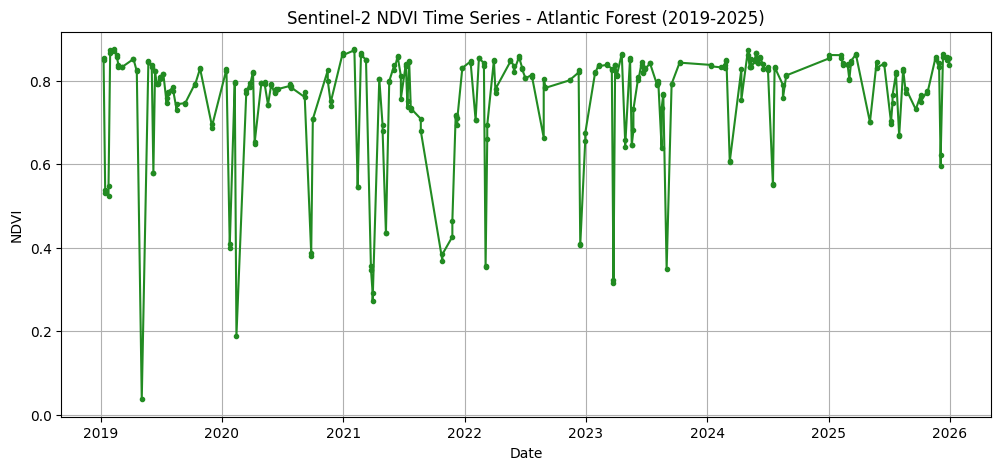

In [ ]:
# Plotting
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['NDVI'], marker='o', linestyle='-', color='forestgreen', markersize=3)
plt.title('Sentinel-2 NDVI Time Series - Atlantic Forest (2019-2025)')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.grid(True)
plt.show()

## Working with all ROI together for comparison


Extracting data for caatinga...
Extracting data for atlantic_forest...
Extracting data for pampa...
Extracting data for pantanal...
Extraction complete! Preparing chart...


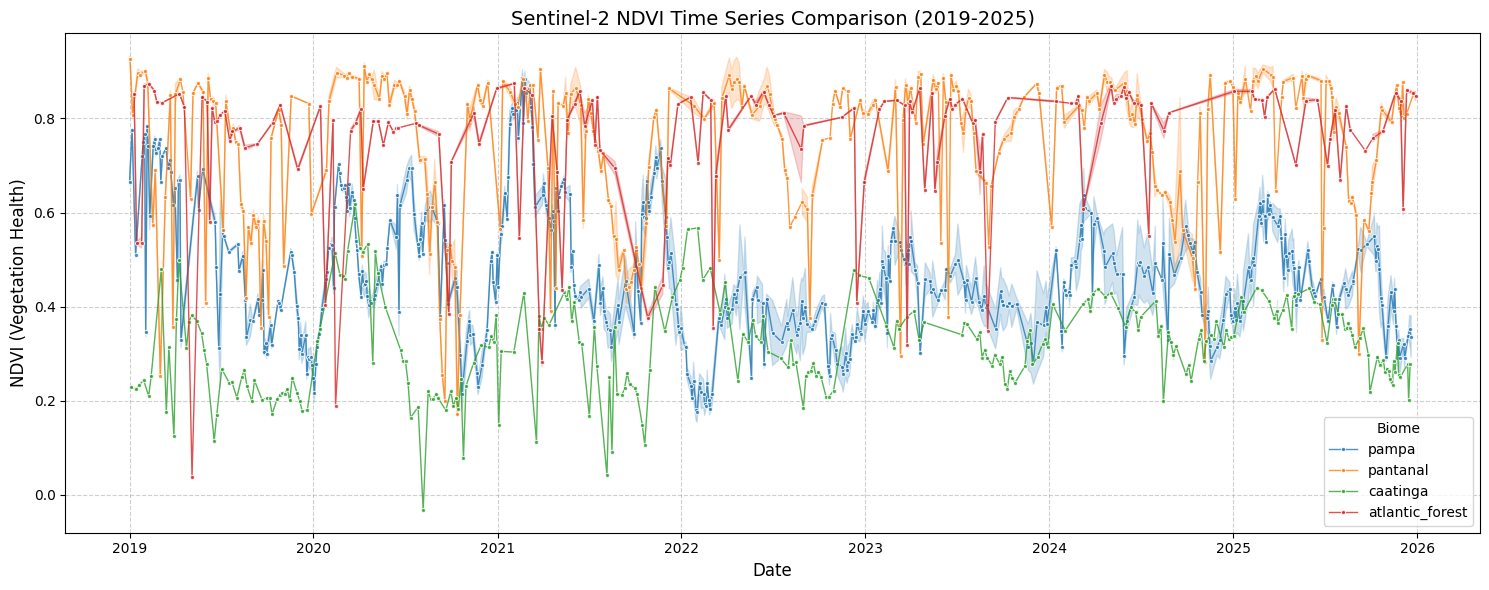

In [ ]:
all_data = []

# 3. Loop through biomes ONE by ONE to save memory
for name, point in biomes.items():
    print(f"Extracting data for {name}...")

    # Filter the collection specifically for this single point
    local_col = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(point) \
        .filterDate('2019-01-01', '2025-12-31') \
        .map(maskS2clouds) \
        .map(addNDVI)

    # Function to extract NDVI at this single point
    def extract_point(image):
        mean_dict = image.select('NDVI').reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=10
        )
        date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
        return ee.Feature(None, {'Date': date, 'NDVI': mean_dict.get('NDVI')})

    # Apply extraction
    ts_features = local_col.map(extract_point)

    # CRITICAL MEMORY OPTIMIZATION:
    # Drop dates where NDVI is null (clouds/shadows) BEFORE bringing data to Python
    ts_features = ts_features.filter(ee.Filter.notNull(['NDVI']))

    # Pull data to Python (getInfo is safe now because the payload is small)
    ts_data = ts_features.getInfo()['features']

    # Append to our Python list
    for feat in ts_data:
        all_data.append({
            'Date': feat['properties']['Date'],
            'NDVI': feat['properties']['NDVI'],
            'Biome': name
        })

print("Extraction complete! Preparing chart...")

# 4. Create DataFrame and Plot
df = pd.DataFrame(all_data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Plotting
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='Date', y='NDVI', hue='Biome', marker='o', markersize=3, linewidth=1, alpha=0.8)

# Formatting the chart
plt.title('Sentinel-2 NDVI Time Series Comparison (2019-2025)', fontsize=14)
plt.ylabel('NDVI (Vegetation Health)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(title='Biome')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

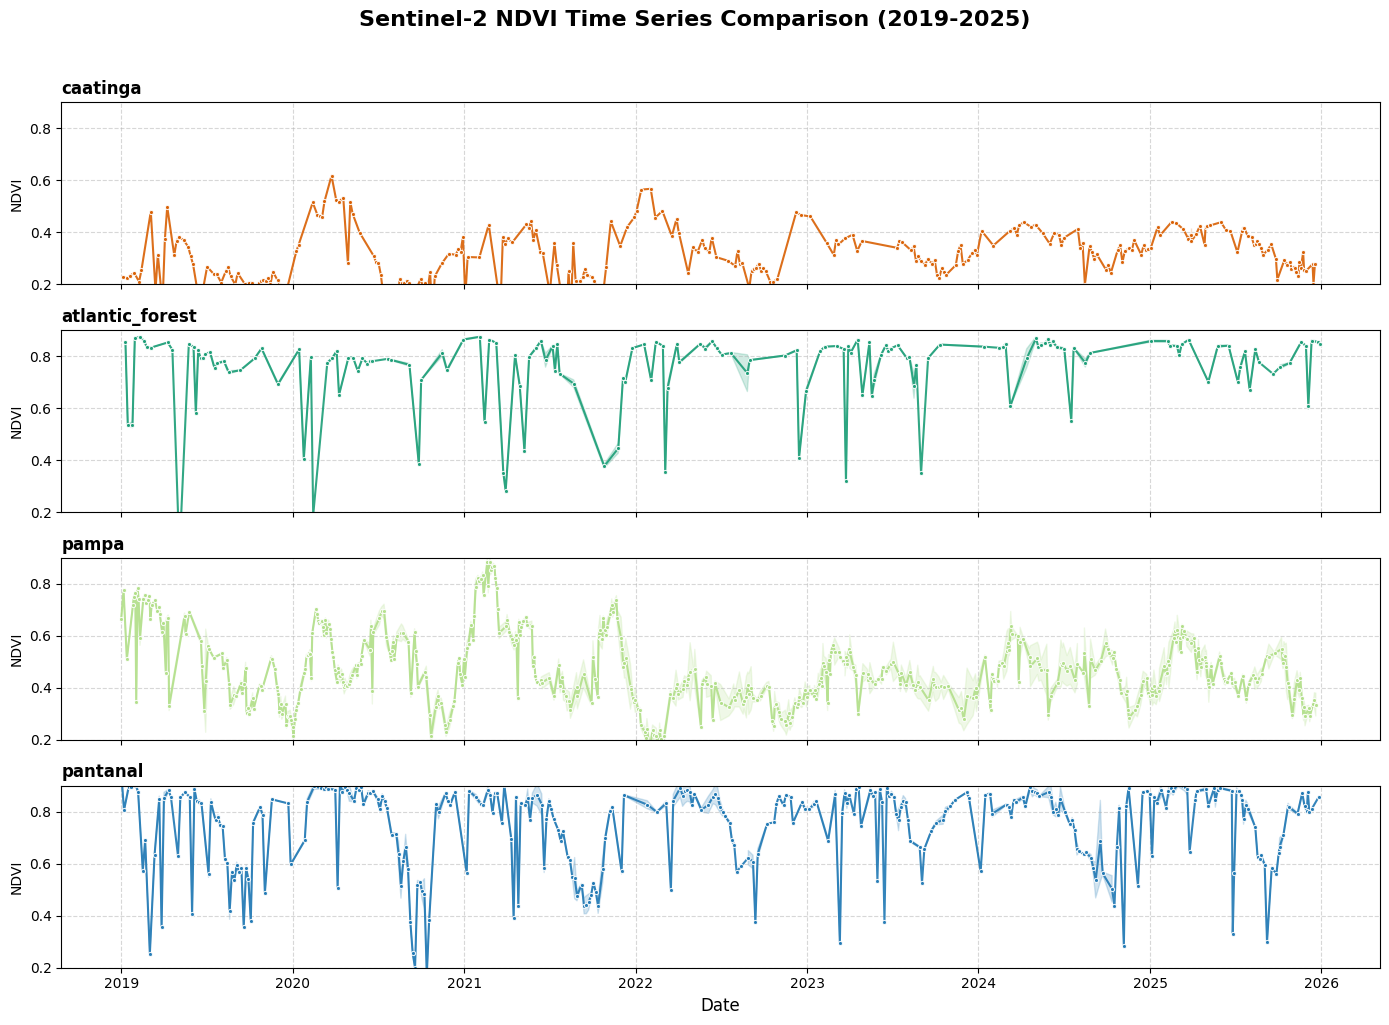

In [ ]:
# Define custom, ecologically meaningful colors using Hex codes
biome_colors = {
    'caatinga': '#d95f02',        # Orange/Rust for semi-arid
    'atlantic_forest': '#1b9e77', # Deep Forest Green
    'pampa': '#b2df8a',           # Light Grass Green
    'pantanal': '#1f78b4'         # Blue/Teal for wetlands
}

# Create subplots (4 rows, 1 column) sharing the same X-axis (Dates)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10), sharex=True)

# Loop through each biome to plot them on their specific subplot axis (ax)
for i, biome_name in enumerate(biomes.keys()):
    ax = axes[i]
    # Filter data for just this biome
    biome_data = df[df['Biome'] == biome_name]

    sns.lineplot(
        data=biome_data,
        x='Date',
        y='NDVI',
        ax=ax,
        color=biome_colors[biome_name],
        marker='o', markersize=3, linewidth=1.5, alpha=0.9
    )

    # Formatting each individual subplot
    ax.set_title(f'{biome_name}', fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('NDVI')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Optional: Keep y-axis limits uniform (0.2 to 0.9) for fair visual comparison across biomes
    ax.set_ylim(0.2, 0.9)

# Only show the X-axis label on the bottom plot
axes[-1].set_xlabel('Date', fontsize=12)

# Add a main title for the whole figure
plt.suptitle('Sentinel-2 NDVI Time Series Comparison (2019-2025)', fontsize=16, fontweight='bold', y=1.02)

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

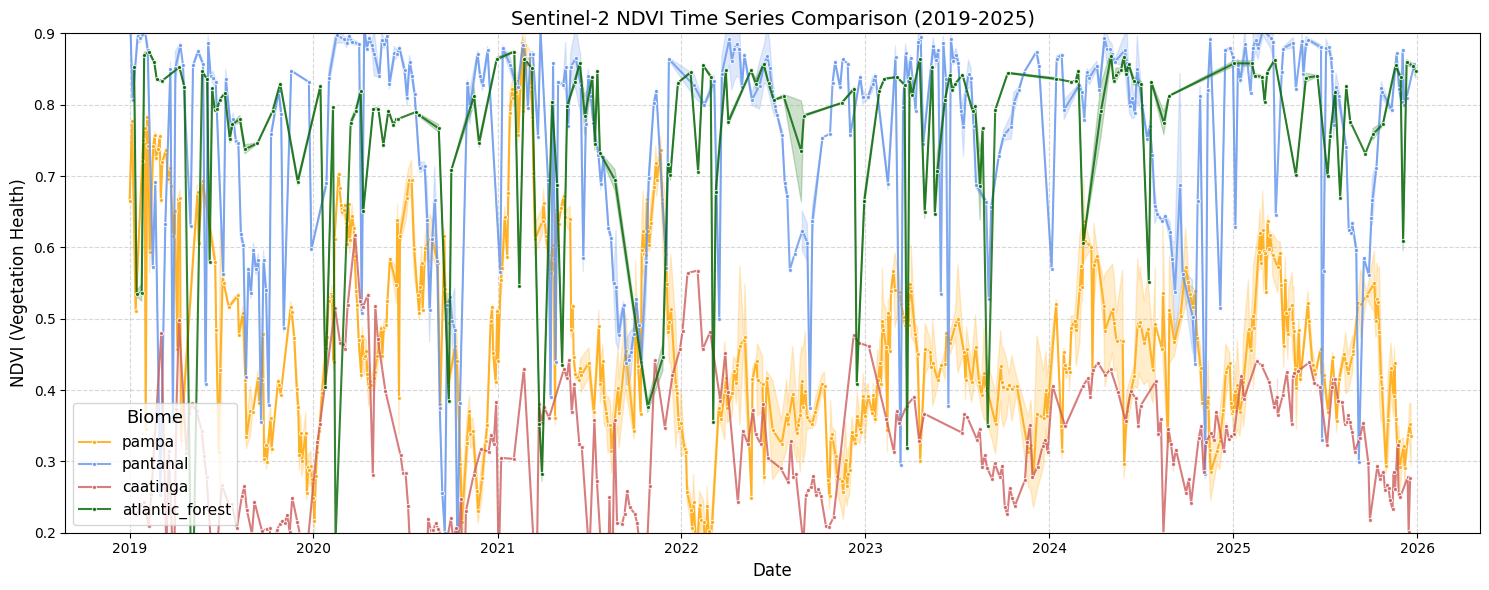

In [ ]:
# Plotting - define different colors
biome_colors = {
    'caatinga': 'indianred',        # Orange/Rust for semi-arid
    'atlantic_forest': 'darkgreen', # Deep Forest Green
    'pampa': 'orange',           # Light Grass Green
    'pantanal': 'cornflowerblue'         # Blue/Teal for wetlands
}
plt.figure(figsize=(15, 6))
# Overplot using Seaborn, applying the custom palette
sns.lineplot(
    data=df,
    x='Date',
    y='NDVI',
    hue='Biome',          # Differentiates the lines by Biome
    palette=biome_colors, # Applies our custom colors
    marker='o',
    markersize=3,
    linewidth=1.5,
    alpha=0.8
)

# Formatting the chart
plt.title('Sentinel-2 NDVI Time Series Comparison (2019-2025)', fontsize=14)
plt.ylabel('NDVI (Vegetation Health)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.2, 0.9) # Keep y-axis limits consistent

# Customize the legend
plt.legend(title='Biome', title_fontsize='13', fontsize='11', loc='lower left')

plt.tight_layout()
plt.show()

The plot presents **Sentinel-2 NDVI Time Series Comparison (2019–2025)**, illustrating how vegetation health—measured by the Normalized Difference Vegetation Index (NDVI)—fluctuates seasonally across four distinct Brazilian biomes.

### Key Insights from the Visualization:

* **Atlantic Forest:** This biome maintains the highest and most stable NDVI values ($0.7$ -- $0.9$), indicating a dense, multi-layered, and green canopy that maintains high photosynthetic activity throughout the year.

* **Pantanal:** This biome shows high volatility. NDVI values often reach $0.9$ during peak growth but crash significantly during dry or flooding periods, indicating the seasonal cycle of vegetation.

* **Pampa:** Shows a moderate, oscillating pattern ($0.3$ -- $0.6$). As a grassland/shrubland system the oscillations may represent the natural cycle of the grass cover, which responds quickly to rainfall.

* **Caatinga:** This semi-arid biome shows the lowest NDVI values, often dropping near $0.2$ indicating a landscape that experiences significant browning (leaf drop) during the dry season and rapid "greening up" only when rainfall is sufficient.


### Technical Interpretation:

- **Noise and Masking:** The vertical spikes—where lines suddenly drop toward zero and then recover—represent moments where cloud cover or shadows were either not perfectly masked or where the sensor detected a brief, extreme environmental change (like a fire or localized flooding).

- **Shaded Areas:** The lighter shaded regions around the lines represent the variance (uncertainty) in the data. Where the shaded region is wide, it suggests that the satellite detected high spatial heterogeneity in that biome at that moment, perhaps due to mixed land cover or partial cloud presence.

This plot demonstrates that **one single threshold cannot be used for all biomes.** For example, an NDVI of $0.5$ might indicate "healthy" vegetation in the Pampa, but would represent a "degraded" or "browned" state in the Atlantic Forest.